# Youth Opportunity Index Poster Figures

This notebook generates the core figures for the Youth Opportunity Index poster using the current processed outputs in the repo.

Figures produced:
1. Overall YOI map across San Diego County tracts
2. Most common weakest domains among the 20 lowest-YOI tracts
3. Domain score heatmap for the 5 lowest-YOI tracts
4. YOI vs COI side-by-side comparison map
5. Service-density chart for the lowest-YOI tracts
6. Optional methods/pipeline schematic

Outputs are saved to `poster_figures/`.

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# cleaner continuous version of your dashboard palette
yoi_cmap = LinearSegmentedColormap.from_list(
    "yoi_clean",
    ["#B6442C", "#E59A22", "#EEC574", "#7CC6BB", "#2B989E", "#246E7E", "#27373D"]
)

In [15]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

def savefig_clean(fig, filename):
    path = OUT / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path}")
    plt.close(fig)

def tract_label_from_geoid(geoid):
    geoid = normalize_geoid(geoid)
    if not geoid:
        return "Census tract"
    tract_suffix = geoid[5:]
    return f"{int(tract_suffix[:4])}.{tract_suffix[4:]}"

NameError: name 'gdf' is not defined

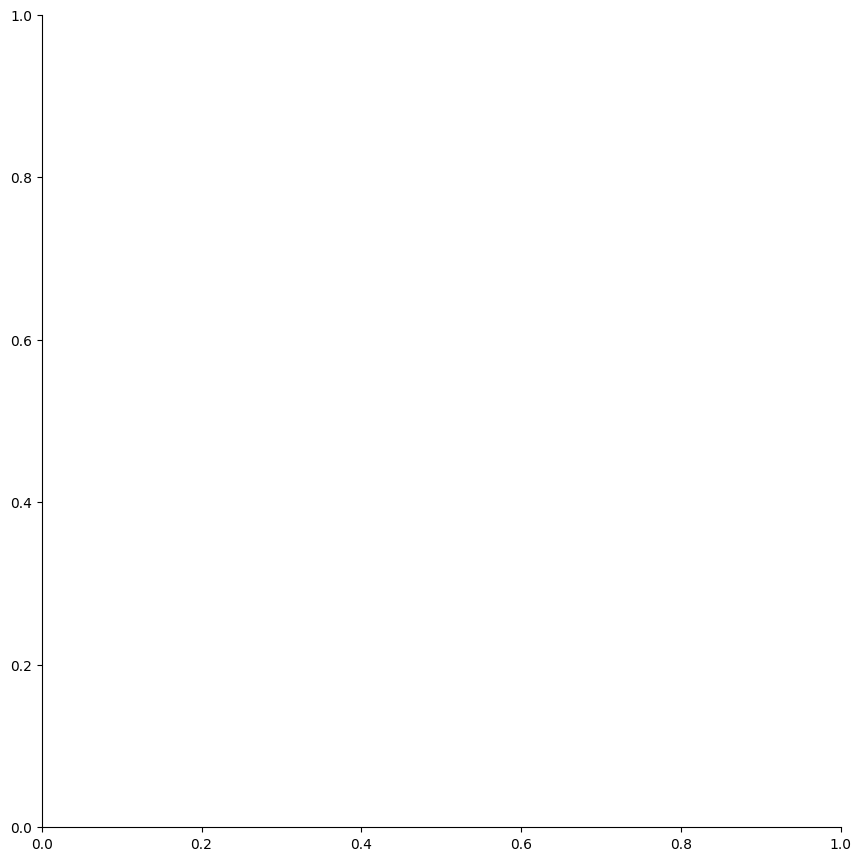

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 8.5), constrained_layout=True)

plot_df = gdf.dropna(subset=[OVERALL_COL]).copy()

plot_df.plot(
    column=OVERALL_COL,
    cmap=yoi_cmap,
    linewidth=0.15,
    edgecolor=(1, 1, 1, 0.18),
    ax=ax,
    vmin=0,
    vmax=100
)

# outline lowest 5 tracts
bottom5_map = plot_df.nsmallest(5, OVERALL_COL).copy()
bottom5_map.boundary.plot(ax=ax, color="black", linewidth=0.8)

for _, row in bottom5_map.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x, pt.y,
        tract_label_from_geoid(row["tract_geoid"]),
        fontsize=8,
        weight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85)
    )

# add compact colorbar
sm = plt.cm.ScalarMappable(cmap=yoi_cmap, norm=plt.Normalize(vmin=0, vmax=100))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.72, pad=0.01)
cbar.set_label("Overall YOI (0–100)")

ax.set_axis_off()
# no giant title here — put title in poster, not inside figure
savefig_clean(fig, "fig1_yoi_map_clean.png")

In [ ]:
bottom20 = df.nsmallest(20, OVERALL_COL).copy()
bottom20["weakest_domain"] = bottom20[score_cols].idxmin(axis=1).map(DOMAIN_COLS)

counts = bottom20["weakest_domain"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)

bars = ax.barh(counts.index, counts.values, color="#246E7E", height=0.62)

for bar, value in zip(bars, counts.values):
    ax.text(
        value + 0.1,
        bar.get_y() + bar.get_height()/2,
        f"{value}",
        va="center",
        ha="left",
        fontsize=10
    )

ax.set_xlabel("Number of tracts")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.18)
ax.set_axisbelow(True)

savefig_clean(fig, "fig2_weakest_domains_clean.png")

Saved /Users/laurenvo/Documents/github/youth_opportunity_index/notebooks/poster_figures/fig2_weakest_domains_clean.png


In [ ]:
bottom5_heat = df.nsmallest(5, OVERALL_COL).copy()
bottom5_heat["tract_label"] = bottom5_heat["tract_geoid"].map(tract_label_from_geoid)

heat = bottom5_heat.set_index("tract_label")[score_cols].copy()
heat.columns = [DOMAIN_COLS[c] for c in heat.columns]
heat = heat * 100

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)

im = ax.imshow(heat.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9, color="black")

cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label("Domain score (0–100)")

savefig_clean(fig, "fig3_bottom5_heatmap_clean.png")

Saved /Users/laurenvo/Documents/github/youth_opportunity_index/notebooks/poster_figures/fig3_bottom5_heatmap_clean.png


In [ ]:
if "coi_score" not in gdf.columns or gdf["coi_score"].dropna().empty:
    print("Skipping COI comparison figure because coi_score is missing.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.3), constrained_layout=True)

    # left: YOI
    gdf.dropna(subset=[OVERALL_COL]).plot(
        column=OVERALL_COL,
        cmap=yoi_cmap,
        linewidth=0.12,
        edgecolor=(1, 1, 1, 0.16),
        ax=axes[0],
        vmin=0,
        vmax=100
    )
    axes[0].set_title("YOI", fontsize=13, weight="bold")
    axes[0].set_axis_off()

    # right: COI
    gdf.dropna(subset=["coi_score"]).plot(
        column="coi_score",
        cmap=yoi_cmap,
        linewidth=0.12,
        edgecolor=(1, 1, 1, 0.16),
        ax=axes[1],
        vmin=0,
        vmax=100
    )
    axes[1].set_title("COI", fontsize=13, weight="bold")
    axes[1].set_axis_off()

    sm = plt.cm.ScalarMappable(cmap=yoi_cmap, norm=plt.Normalize(vmin=0, vmax=100))
    sm._A = []
    cbar = fig.colorbar(sm, ax=axes, shrink=0.8, pad=0.02)
    cbar.set_label("Score")

    savefig_clean(fig, "fig4_yoi_vs_coi_clean.png")

Saved /Users/laurenvo/Documents/github/youth_opportunity_index/notebooks/poster_figures/fig4_yoi_vs_coi_clean.png


In [ ]:
!pip install scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.cluster import KMeans

# -----------------------------
# helper functions
# -----------------------------
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / s.std()

def tract_short(geoid):
    s = str(geoid)
    last6 = s[-6:]
    whole = int(last6[:4])
    dec = last6[4:]
    return f"{whole}.{dec}"

# -----------------------------
# resolve key columns
# -----------------------------
TRACT_COL = pick_col(yoi, ["tract_geoid", "GEOID", "geoid"])
YOI_COL = pick_col(yoi, ["yoi_custom_0_100", "yoi_0_100", "yoi_raw_0_1"])
POP_COL = pick_col(yoi, ["total_population", "population", "pop_total"])
YOUTH_SERV_COL = pick_col(yoi, ["youth_services_per_10k", "services_per_10k"])
YOUTH_SUPPORTS_COL = pick_col(yoi, ["youth_supports_score"])

DOMAIN_COLS = [
    pick_col(yoi, ["economic_score"]),
    pick_col(yoi, ["education_score"]),
    pick_col(yoi, ["health_score"]),
    pick_col(yoi, ["housing_score"]),
    pick_col(yoi, ["safety_env_score"]),
    pick_col(yoi, ["mobility_connectivity_score"]),
    pick_col(yoi, ["youth_supports_score"]),
]

DOMAIN_LABELS = [
    "Economic",
    "Education",
    "Health",
    "Housing",
    "Safety / Env",
    "Mobility / Connectivity",
    "Youth Supports",
]

# make sure tract IDs are strings
yoi[TRACT_COL] = yoi[TRACT_COL].astype(str)

# identify tract ID column in tracts
TRACTS_GEOID_COL = pick_col(tracts, ["tract_geoid", "GEOID", "geoid"])
tracts[TRACTS_GEOID_COL] = tracts[TRACTS_GEOID_COL].astype(str)

# merge
gdf = tracts.merge(
    yoi,
    left_on=TRACTS_GEOID_COL,
    right_on=TRACT_COL,
    how="left"
).copy()

# count how many domains are below the county median
domain_medians = yoi[DOMAIN_COLS].median()
yoi["domains_below_median"] = (yoi[DOMAIN_COLS] < domain_medians).sum(axis=1)

# bring it into gdf too
gdf = gdf.drop(columns=["domains_below_median"], errors="ignore").merge(
    yoi[[TRACT_COL, "domains_below_median"]],
    on=TRACT_COL,
    how="left"
)

print("Using columns:")
print("TRACT_COL =", TRACT_COL)
print("YOI_COL =", YOI_COL)
print("POP_COL =", POP_COL)
print("YOUTH_SERV_COL =", YOUTH_SERV_COL)
print("YOUTH_SUPPORTS_COL =", YOUTH_SUPPORTS_COL)
print("DOMAIN_COLS =", DOMAIN_COLS)

Using columns:
TRACT_COL = tract_geoid
YOI_COL = yoi_0_100
POP_COL = total_population
YOUTH_SERV_COL = youth_services_per_10k
YOUTH_SUPPORTS_COL = youth_supports_score
DOMAIN_COLS = ['economic_score', 'education_score', 'health_score', 'housing_score', 'safety_env_score', 'mobility_connectivity_score', 'youth_supports_score']


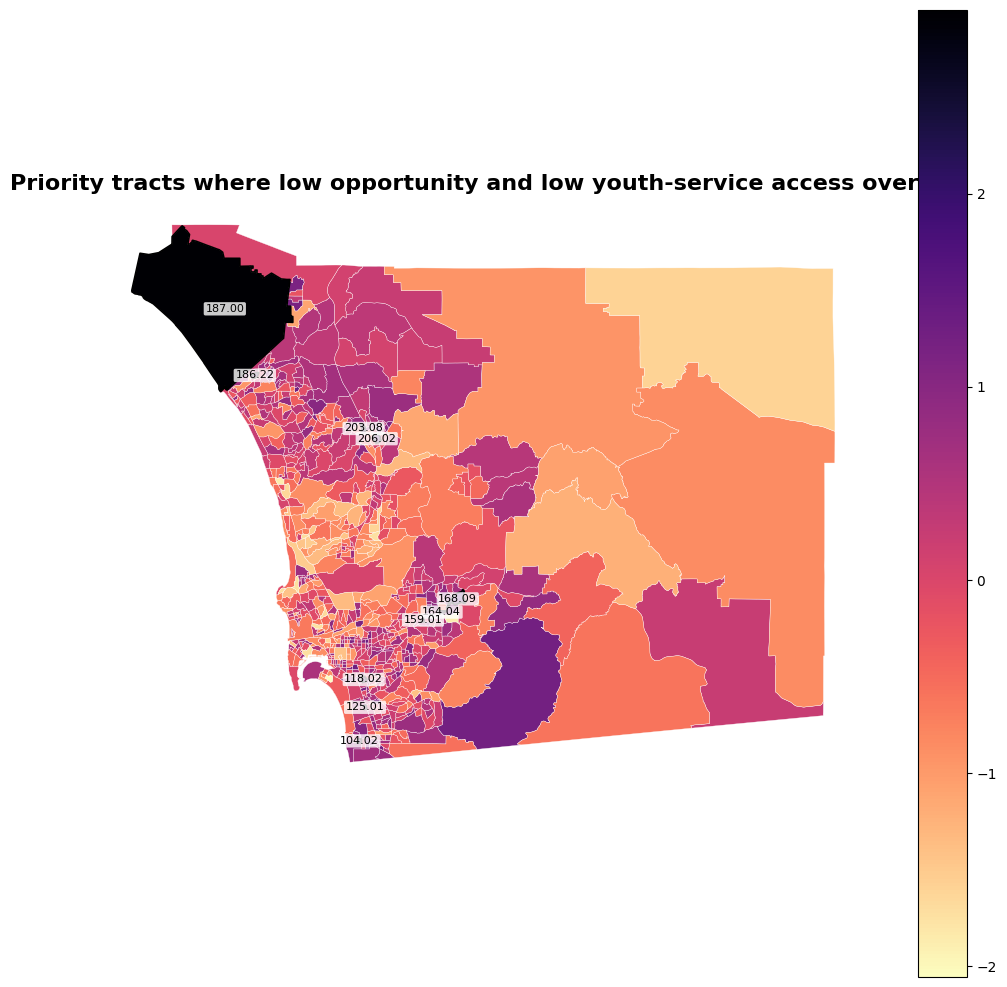

,tract_label,yoi_0_100,youth_supports_score,youth_services_per_10k,total_population,priority_score
247,187.00,44.02,0.44,1.98,40415,2.95
122,118.02,24.20,0.04,0.00,7019,1.66
512,203.08,25.22,0.04,0.00,6685,1.61
69,186.22,26.91,0.04,0.00,5080,1.44
348,206.02,28.82,0.09,0.00,6320,1.41
50,164.04,20.91,0.11,2.43,4110,1.40
9,104.02,25.48,0.10,1.81,5528,1.40
584,168.09,30.86,0.04,0.00,5899,1.38
599,125.01,26.25,0.04,0.00,3905,1.38
355,159.01,23.46,0.12,0.00,3442,1.34


In [ ]:
# ---------------------------------------------
# Figure A: Priority tracts map
# low YOI + low youth supports + low youth services + higher population
# ---------------------------------------------
priority_df = gdf.dropna(subset=[YOI_COL, YOUTH_SUPPORTS_COL, YOUTH_SERV_COL, POP_COL]).copy()

# higher priority = lower opportunity + lower youth supports + lower service density + higher population
priority_df["priority_score"] = (
    0.35 * zscore(100 - priority_df[YOI_COL]) +
    0.30 * zscore(100 - priority_df[YOUTH_SUPPORTS_COL]) +
    0.20 * zscore(-priority_df[YOUTH_SERV_COL]) +
    0.15 * zscore(priority_df[POP_COL])
)

priority_df = priority_df.sort_values("priority_score", ascending=False)
top_priority = priority_df.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 10))
priority_df.plot(
    column="priority_score",
    cmap="magma_r",
    linewidth=0.25,
    edgecolor="white",
    legend=True,
    ax=ax
)

# outline the top-priority tracts
top_priority.boundary.plot(ax=ax, color="black", linewidth=1.2)

# add labels
for _, row in top_priority.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x, pt.y,
        tract_short(row[TRACT_COL]),
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8)
    )

ax.set_title(
    "Priority tracts where low opportunity and low youth-service access overlap",
    fontsize=16,
    weight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.show()

# table of top priority tracts
top_priority_table = top_priority[[TRACT_COL, YOI_COL, YOUTH_SUPPORTS_COL, YOUTH_SERV_COL, POP_COL, "priority_score"]].copy()
top_priority_table["tract_label"] = top_priority_table[TRACT_COL].apply(tract_short)
top_priority_table = top_priority_table[
    ["tract_label", YOI_COL, YOUTH_SUPPORTS_COL, YOUTH_SERV_COL, POP_COL, "priority_score"]
].round(2)

top_priority_table

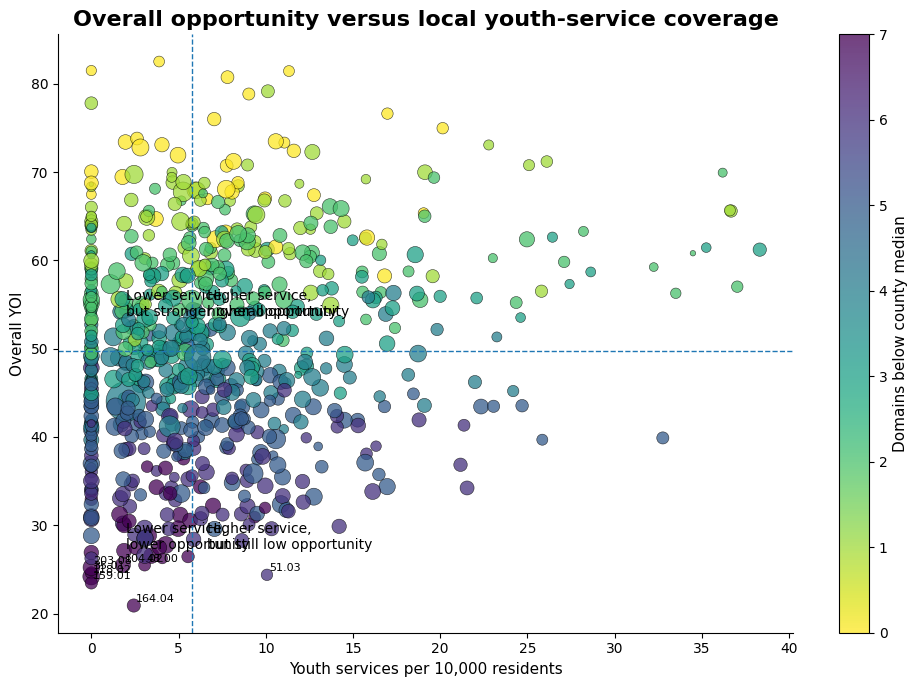

In [ ]:
# ---------------------------------------------
# Figure B: Opportunity vs service coverage
# ---------------------------------------------
scatter_df = yoi.dropna(subset=[YOI_COL, YOUTH_SERV_COL, POP_COL, "domains_below_median"]).copy()

# bubble sizes
size_scale = 800 / scatter_df[POP_COL].max()
bubble_sizes = scatter_df[POP_COL] * size_scale + 10

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    scatter_df[YOUTH_SERV_COL],
    scatter_df[YOI_COL],
    s=bubble_sizes,
    c=scatter_df["domains_below_median"],
    cmap="viridis_r",
    alpha=0.75,
    edgecolors="black",
    linewidths=0.4
)

# median lines
x_med = scatter_df[YOUTH_SERV_COL].median()
y_med = scatter_df[YOI_COL].median()
ax.axvline(x_med, linestyle="--", linewidth=1)
ax.axhline(y_med, linestyle="--", linewidth=1)

# label a few highest-priority or lowest-YOI tracts
label_df = scatter_df.nsmallest(8, YOI_COL).copy()
for _, row in label_df.iterrows():
    ax.text(
        row[YOUTH_SERV_COL] + 0.1,
        row[YOI_COL] + 0.4,
        tract_short(row[TRACT_COL]),
        fontsize=8
    )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Domains below county median")

ax.set_xlabel("Youth services per 10,000 residents")
ax.set_ylabel("Overall YOI")
ax.set_title(
    "Overall opportunity versus local youth-service coverage",
    fontsize=16,
    weight="bold"
)

# quadrant text
ax.text(x_med * 0.35, y_med * 0.55, "Lower service,\nlower opportunity", fontsize=10)
ax.text(x_med * 1.15, y_med * 0.55, "Higher service,\nbut still low opportunity", fontsize=10)
ax.text(x_med * 0.35, y_med * 1.08, "Lower service,\nbut stronger overall opportunity", fontsize=10)
ax.text(x_med * 1.15, y_med * 1.08, "Higher service,\nhigher opportunity", fontsize=10)

plt.tight_layout()
plt.show()

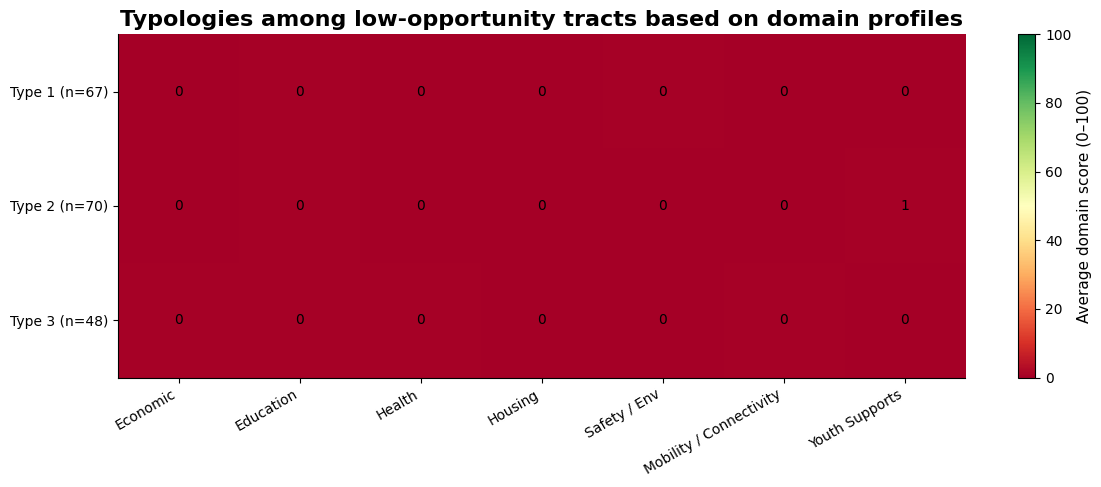

,cluster,tract,overall_yoi,weakest_domain
0,Type 1,164.04,20.907047,Economic
1,Type 1,159.01,23.462606,Economic
2,Type 1,118.02,24.198038,Youth Supports
3,Type 2,51.03,24.383165,Economic
4,Type 2,35.02,28.275648,Economic
5,Type 2,132.06,28.826481,Health
6,Type 3,118.01,30.915478,Economic
7,Type 3,189.06,31.222017,Youth Supports
8,Type 3,133.06,32.826603,Economic


In [ ]:
# ---------------------------------------------
# Figure C: Typologies among low-opportunity tracts
# ---------------------------------------------
low_df = yoi[yoi[YOI_COL] <= yoi[YOI_COL].quantile(0.25)].copy()
cluster_data = low_df[DOMAIN_COLS].copy()

# fill missing values with column medians
cluster_data = cluster_data.fillna(cluster_data.median())

# cluster low-opportunity tracts into 3 groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
low_df["cluster"] = kmeans.fit_predict(cluster_data)

# mean profile by cluster
cluster_profile = low_df.groupby("cluster")[DOMAIN_COLS].mean()
cluster_counts = low_df["cluster"].value_counts().sort_index()

# sort clusters from lowest average YOI to highest average YOI
cluster_order = low_df.groupby("cluster")[YOI_COL].mean().sort_values().index.tolist()
cluster_profile = cluster_profile.loc[cluster_order]
cluster_counts = cluster_counts.loc[cluster_order]

# plot heatmap
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(cluster_profile.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)

ax.set_xticks(range(len(DOMAIN_LABELS)))
ax.set_xticklabels(DOMAIN_LABELS, rotation=30, ha="right")

row_labels = [f"Type {i+1} (n={cluster_counts.iloc[i]})" for i in range(len(cluster_profile))]
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)

# annotate values
for i in range(cluster_profile.shape[0]):
    for j in range(cluster_profile.shape[1]):
        ax.text(j, i, f"{cluster_profile.iloc[i, j]:.0f}",
                ha="center", va="center", fontsize=10)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Average domain score (0–100)")

ax.set_title(
    "Typologies among low-opportunity tracts based on domain profiles",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

# show example tracts in each cluster
examples = []
for cl in cluster_order:
    subset = low_df[low_df["cluster"] == cl].nsmallest(3, YOI_COL)
    for _, row in subset.iterrows():
        examples.append({
            "cluster": f"Type {cluster_order.index(cl)+1}",
            "tract": tract_short(row[TRACT_COL]),
            "overall_yoi": row[YOI_COL],
            "weakest_domain": DOMAIN_LABELS[np.argmin(row[DOMAIN_COLS].values)]
        })

examples_df = pd.DataFrame(examples)
examples_df

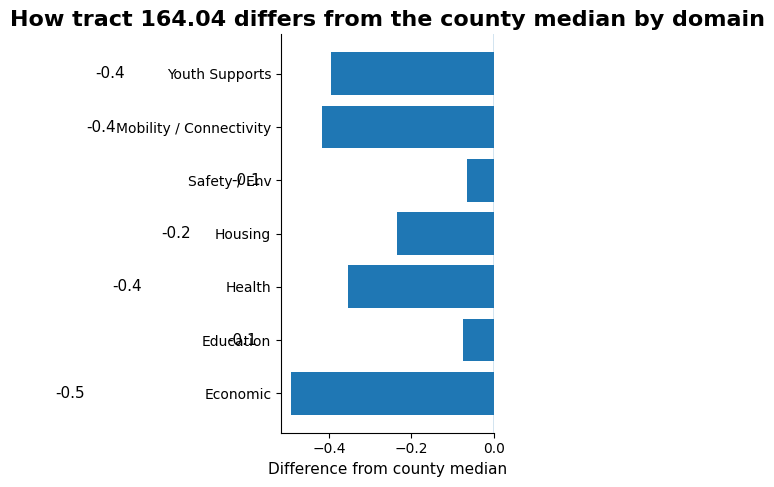

In [ ]:
# ---------------------------------------------
# Figure D: Domain gap chart for one tract
# choose one tract you want to feature
# ---------------------------------------------
FOCUS_TRACT = "06073016404"   # change if needed

focus = yoi[yoi[TRACT_COL].astype(str) == FOCUS_TRACT].copy()
if len(focus) == 0:
    raise ValueError(f"Tract {FOCUS_TRACT} not found")

focus = focus.iloc[0]

focus_scores = [focus[c] for c in DOMAIN_COLS]
county_medians = [yoi[c].median() for c in DOMAIN_COLS]
gaps = np.array(focus_scores) - np.array(county_medians)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(DOMAIN_LABELS, gaps)

ax.axvline(0, linewidth=1)
ax.set_xlabel("Difference from county median")
ax.set_title(
    f"How tract {tract_short(FOCUS_TRACT)} differs from the county median by domain",
    fontsize=16,
    weight="bold"
)

for i, val in enumerate(gaps):
    ax.text(val + (0.5 if val >= 0 else -0.5), i, f"{val:.1f}",
            va="center", ha="left" if val >= 0 else "right")

plt.tight_layout()
plt.show()

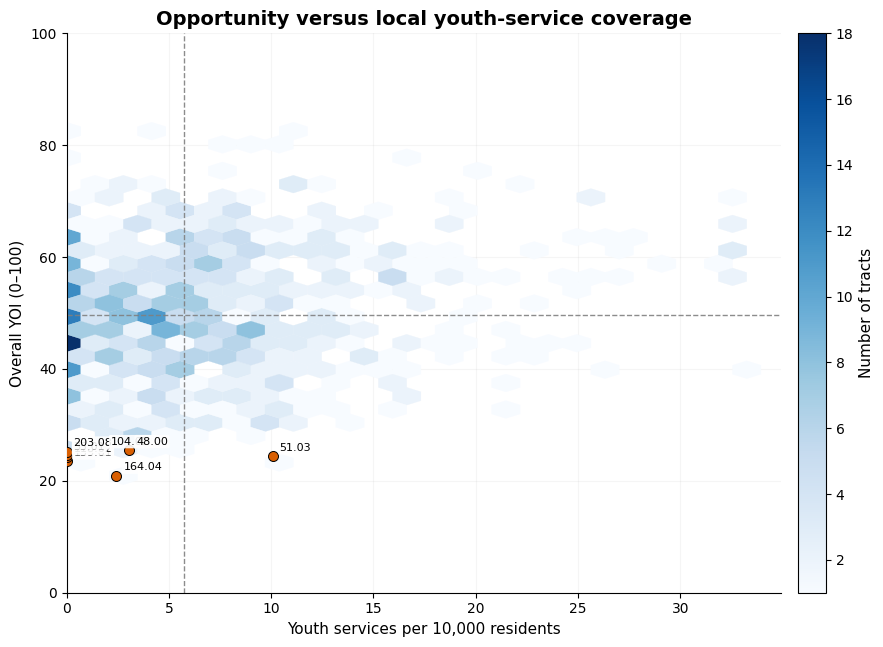

In [17]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# -----------------------------
# repo-aware paths
# -----------------------------
def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing /data")

REPO_ROOT = find_repo_root(Path.cwd())

YOI_CSV = REPO_ROOT / "data" / "processed" / "yoi" / "yoi_components.csv"
TRACTS_GEOJSON = REPO_ROOT / "data" / "processed" / "boundaries" / "sd_tracts.geojson"

# -----------------------------
# helpers
# -----------------------------
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")

def normalize_geoid(v):
    s = "".join(ch for ch in str(v) if ch.isdigit())
    return s.zfill(11)[-11:] if s else None

def tract_short(geoid):
    s = str(geoid)
    last6 = s[-6:]
    return f"{int(last6[:4])}.{last6[4:]}"

# -----------------------------
# load data
# -----------------------------
yoi = pd.read_csv(YOI_CSV, dtype={"tract_geoid": str})
yoi["tract_geoid"] = yoi["tract_geoid"].map(normalize_geoid)

tracts = gpd.read_file(TRACTS_GEOJSON)
tract_geoid_col = pick_col(tracts, ["tract_geoid", "GEOID", "geoid"])
tracts[tract_geoid_col] = tracts[tract_geoid_col].astype(str).map(normalize_geoid)

# -----------------------------
# resolve columns from your current build
# -----------------------------
TRACT_COL = "tract_geoid"
YOI_COL = "yoi_custom_0_100" if "yoi_custom_0_100" in yoi.columns else "yoi_0_100"
POP_COL = pick_col(yoi, ["total_population", "population", "pop_total"])
YOUTH_SERV_COL = pick_col(yoi, ["youth_services_per_10k", "services_per_10k"])

DOMAIN_COLS = [
    "economic_score",
    "education_score",
    "health_score",
    "housing_score",
    "safety_env_score",
    "mobility_connectivity_score",
    "youth_supports_score",
]

domain_medians = yoi[DOMAIN_COLS].median()
yoi["domains_below_median"] = (yoi[DOMAIN_COLS] < domain_medians).sum(axis=1)

# -----------------------------
# Figure B final: hexbin + highlighted low-opportunity tracts
# -----------------------------
plot_df = yoi.dropna(subset=[YOI_COL, YOUTH_SERV_COL, POP_COL]).copy()

if plot_df[YOI_COL].max() <= 1.5:
    plot_df["yoi_display"] = plot_df[YOI_COL] * 100
else:
    plot_df["yoi_display"] = plot_df[YOI_COL]

x_cap = plot_df[YOUTH_SERV_COL].quantile(0.99)
plot_df["service_display"] = plot_df[YOUTH_SERV_COL].clip(upper=x_cap)

fig, ax = plt.subplots(figsize=(9.5, 6.6))

hb = ax.hexbin(
    plot_df["service_display"],
    plot_df["yoi_display"],
    gridsize=24,
    mincnt=1,
    cmap="Blues",
    linewidths=0.2
)

highlight = plot_df.nsmallest(8, "yoi_display").copy()
ax.scatter(
    highlight["service_display"],
    highlight["yoi_display"],
    s=52,
    facecolors="#D95F02",
    edgecolors="black",
    linewidths=0.7,
    zorder=3
)

for _, row in highlight.iterrows():
    ax.annotate(
        tract_short(row[TRACT_COL]),
        (row["service_display"], row["yoi_display"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9),
        zorder=4
    )

x_med = plot_df["service_display"].median()
y_med = plot_df["yoi_display"].median()
ax.axvline(x_med, linestyle="--", linewidth=1.0, color="gray", alpha=0.9)
ax.axhline(y_med, linestyle="--", linewidth=1.0, color="gray", alpha=0.9)

cbar = plt.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Number of tracts")

ax.set_xlabel("Youth services per 10,000 residents")
ax.set_ylabel("Overall YOI (0–100)")
ax.set_title("Opportunity versus local youth-service coverage", fontsize=14, weight="bold")

ax.grid(alpha=0.12)
ax.set_axisbelow(True)
ax.set_xlim(left=0)
ax.set_ylim(0, max(100, plot_df["yoi_display"].max() + 2))

plt.tight_layout()
plt.show()

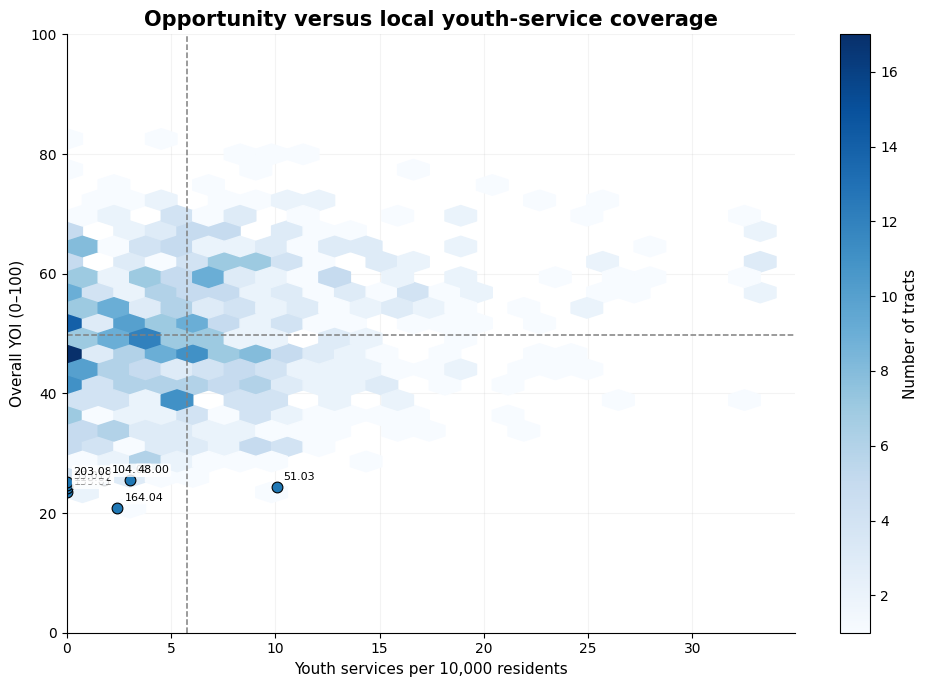

In [18]:
# ---------------------------------------------
# Figure B alternative: hexbin + highlighted low-opportunity tracts
# ---------------------------------------------
plot_df = yoi.dropna(subset=[YOI_COL, YOUTH_SERV_COL, POP_COL]).copy()

if plot_df[YOI_COL].max() <= 1.5:
    plot_df["yoi_display"] = plot_df[YOI_COL] * 100
else:
    plot_df["yoi_display"] = plot_df[YOI_COL]

x_cap = plot_df[YOUTH_SERV_COL].quantile(0.99)
plot_df["service_display"] = plot_df[YOUTH_SERV_COL].clip(upper=x_cap)

fig, ax = plt.subplots(figsize=(10, 7))

hb = ax.hexbin(
    plot_df["service_display"],
    plot_df["yoi_display"],
    gridsize=22,
    mincnt=1,
    cmap="Blues"
)

# highlight lowest-YOI tracts
highlight = plot_df.nsmallest(8, "yoi_display").copy()
ax.scatter(
    highlight["service_display"],
    highlight["yoi_display"],
    s=60,
    edgecolors="black",
    linewidths=0.8
)

for _, row in highlight.iterrows():
    ax.annotate(
        tract_short(row[TRACT_COL]),
        (row["service_display"], row["yoi_display"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85)
    )

x_med = plot_df["service_display"].median()
y_med = plot_df["yoi_display"].median()
ax.axvline(x_med, linestyle="--", linewidth=1.1, color="gray")
ax.axhline(y_med, linestyle="--", linewidth=1.1, color="gray")

cbar = plt.colorbar(hb, ax=ax)
cbar.set_label("Number of tracts")

ax.set_xlabel("Youth services per 10,000 residents")
ax.set_ylabel("Overall YOI (0–100)")
ax.set_title("Opportunity versus local youth-service coverage", fontsize=15, weight="bold")
ax.grid(alpha=0.15)
ax.set_axisbelow(True)
ax.set_xlim(left=0)
ax.set_ylim(0, max(100, plot_df["yoi_display"].max() + 3))

plt.tight_layout()
plt.show()